#Assignment 1. Digital Signal Processing

##Training a simple CNN model with **LogMelFilterBanks** features for a binary classification problem with PyTorch on Google Speech Commands data

In [ ]:
%%capture

!pip install ptflops

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import sys

import matplotlib.pyplot as plt
import IPython.display as ipd

from ptflops import get_model_complexity_info
from tqdm import tqdm

from typing import Optional


In [ ]:
import os
import time
import pandas as pd

In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


In [ ]:
from torchaudio.datasets import SPEECHCOMMANDS


dataset = SPEECHCOMMANDS(root="./", download=True)


In [ ]:
type(dataset)

torchaudio.datasets.speechcommands.SPEECHCOMMANDS

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


##Handling data

In [ ]:
class SubsetSC(SPEECHCOMMANDS):
    def __init__(self, subset: str = None):
        super().__init__("./", download=True)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath) as fileobj:
                return [os.path.normpath(os.path.join(self._path, line.strip())) for line in fileobj]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = load_list("validation_list.txt") + load_list("testing_list.txt")
            excludes = set(excludes)
            self._walker = [w for w in self._walker if w not in excludes]

In [ ]:
# Creating train/val/test splits of the data

train_set = SubsetSC("training")
test_set = SubsetSC("testing")
val_set = SubsetSC("validation")

In [ ]:
# Switching classification task to a binary one

train_yesno = [sample for sample in train_set if sample[2] in ["yes", "no"]]
val_yesno = [sample for sample in val_set if sample[2] in ["yes", "no"]]
test_yesno = [sample for sample in test_set if sample[2] in ["yes", "no"]]


In [ ]:
train_yesno[0]

(tensor([[0.0072, 0.0061, 0.0055,  ..., 0.0098, 0.0085, 0.0092]]),
 16000,
 'no',
 '012c8314',
 0)

In [ ]:
class YesNoDataset(Dataset):
    def __init__(self, data, logmel_transform):
        self.data = data
        self.logmel = logmel_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        waveform, _, label, *_ = self.data[idx]
        target = 1 if label == "yes" else 0
        max_len = 16000
        if waveform.shape[1] < max_len:
          pad_len = max_len - waveform.shape[1]
          waveform = torch.nn.functional.pad(waveform, (0, pad_len))
        else:
          waveform = waveform[:, :max_len]

        features = self.logmel(waveform.unsqueeze(0))
        features = features.squeeze(0)

        target = 1 if label == "yes" else 0
        return features, target



In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
# taking this class from the previous task

class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()

        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft

        self.register_buffer("window", torch.hann_window(self.window_length))
        # Do correct initialization of stft params below:

        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # Do correct initialization of mel fbanks params below:

        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):

        return F.melscale_fbanks(
            # Turns a normal STFT into a mel frequency STFT with triangular filter banks

            n_freqs=self.n_fft // 2 + 1,
            f_min = self.f_min_hz,
            f_max = self.samplerate // 2 if self.f_max_hz is None else self.f_max_hz,
            n_mels = self.n_mels,
            sample_rate = self.samplerate,
            norm = self.norm_mel,
            mel_scale = self.mel_scale,
            )

    def spectrogram(self, x):
      x = x.squeeze(1)
      specs = []
      for sample in x:
        spec =  torch.stft(
            input = sample,
            n_fft=self.n_fft,
            hop_length = self.hop_length,
            win_length = self.window_length,
            window = self.window,
            center = self.center,
            pad_mode = self.pad_mode,
            return_complex = self.return_complex,
            onesided = self.onesided,
            normalized = self.normalize_stft,
            )
        power_spec = spec.abs() ** self.power
        specs.append(power_spec)
      return torch.stack(specs)


    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        spec = self.spectrogram(x)
        spec = spec.transpose(1, 2)

        mel_spec = torch.matmul(spec, self.mel_fbanks)
        mel_spec = mel_spec.transpose(1, 2)

        log_mel = torch.log(mel_spec + 1e-6)


        return log_mel

In [ ]:
# class SimpleCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv = nn.Conv1d(n_mels, 128, kernel_size=5)
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(128, 1)

#     def forward(self, x):
#         x = self.conv(x)
#         x = torch.relu(x)
#         x = self.pool(x)
#         x = x.squeeze(-1)
#         x = self.fc(x)
#         return x.squeeze(1)


In [ ]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    start_time = time.time()

    for x, y in tqdm(dataloader):
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(logits) > 0.5
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_time = time.time() - start_time
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy, epoch_time


In [ ]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device).float()

            logits = model(x)
            loss = loss_fn(logits, y)

            total_loss += loss.item()

            preds = torch.sigmoid(logits) > 0.5
            correct += (preds == y).sum().item()
            total += y.size(0)

    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy


In [ ]:
def run_experiment(n_mels=80, groups=1, batch_size=32, epochs=10):
    print(f"\n n_mels={n_mels}, groups={groups}, epochs={epochs}")

    # LogMel layer
    logmel = LogMelFilterBanks(n_mels=n_mels)

    # datasets we need
    train_ds = YesNoDataset(train_yesno, logmel)
    val_ds = YesNoDataset(val_yesno, logmel)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    # model
    class SimpleCNN(nn.Module):
        def __init__(self, n_mels, groups=1):
            super().__init__()
            self.conv = nn.Conv1d(n_mels, 128, kernel_size=5, groups=groups)
            self.pool = nn.AdaptiveAvgPool1d(1)
            self.fc = nn.Linear(128, 1)

        def forward(self, x):
            x = self.conv(x)
            x = torch.relu(x)
            x = self.pool(x)
            x = x.squeeze(-1)
            x = self.fc(x)
            return x.squeeze(1)

    model = SimpleCNN(n_mels=n_mels, groups=groups)

    # optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    # metrics
    macs, params = get_model_complexity_info(
        model,
        input_res=(n_mels, 101),
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False,
    )
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


    all_train_loss = []
    all_train_acc = []
    all_val_loss = []
    all_val_acc = []
    start = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        # one epoch training
        train_loss, train_acc, _ = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        all_train_loss.append(train_loss)
        all_train_acc.append(train_acc)
        all_val_loss.append(val_loss)
        all_val_acc.append(val_acc)

    train_time = time.time() - start

    return {
        "n_mels": n_mels,
        "groups": groups,
        "train_loss": all_train_loss,
        "val_loss": all_val_loss,
        "train_acc": all_train_acc,
        "val_acc": all_val_acc,
        "train_time": train_time,
        "params": total_params,
        "flops": macs / 1e6
    }


In [ ]:
result1 = run_experiment(n_mels=20)
result2 = run_experiment(n_mels=40)
result3 = run_experiment(n_mels=80)



 n_mels=20, groups=1, epochs=10
Epoch 1/10


100%|██████████| 199/199 [00:07<00:00, 26.47it/s]


Epoch 2/10


100%|██████████| 199/199 [00:07<00:00, 28.23it/s]


Epoch 3/10


...

100%|██████████| 199/199 [00:09<00:00, 20.29it/s]


Epoch 9/10


100%|██████████| 199/199 [00:09<00:00, 21.28it/s]


Epoch 10/10


100%|██████████| 199/199 [00:10<00:00, 19.83it/s]


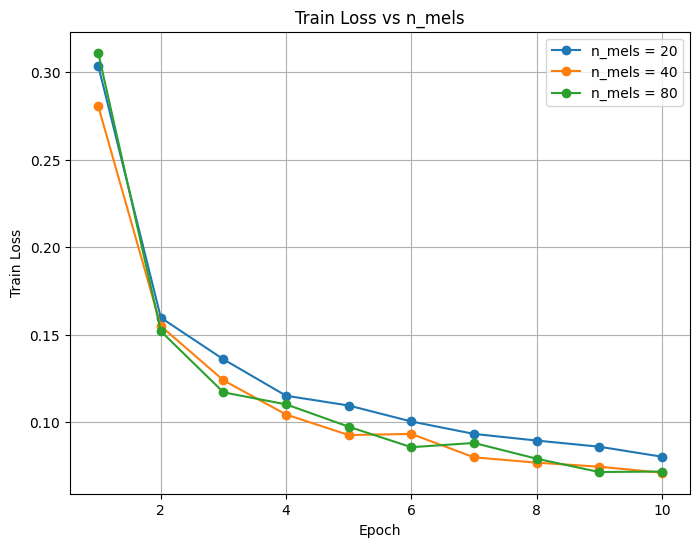

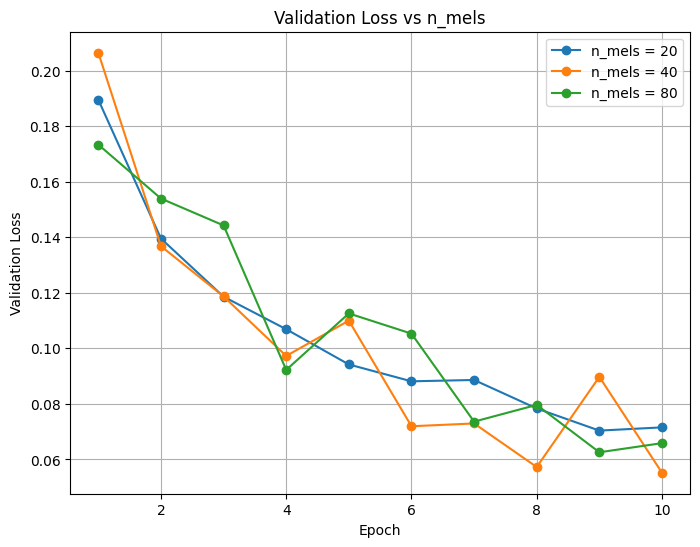

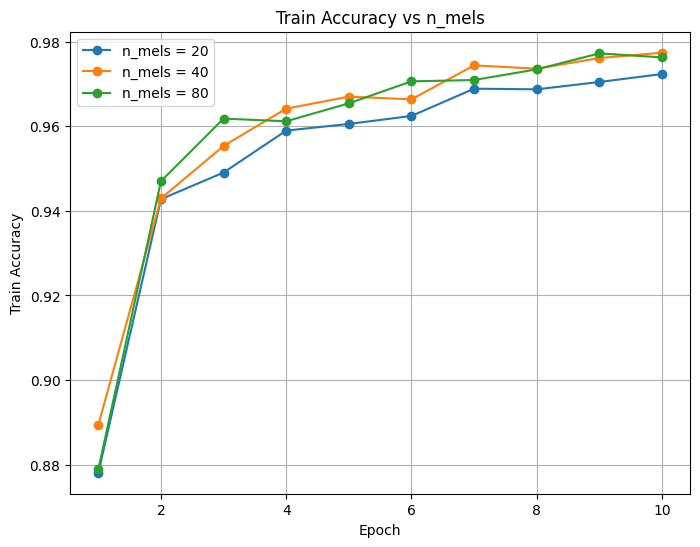

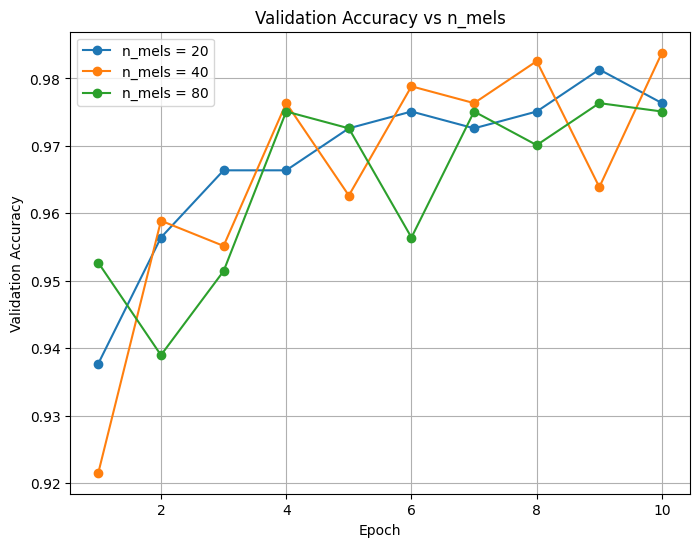

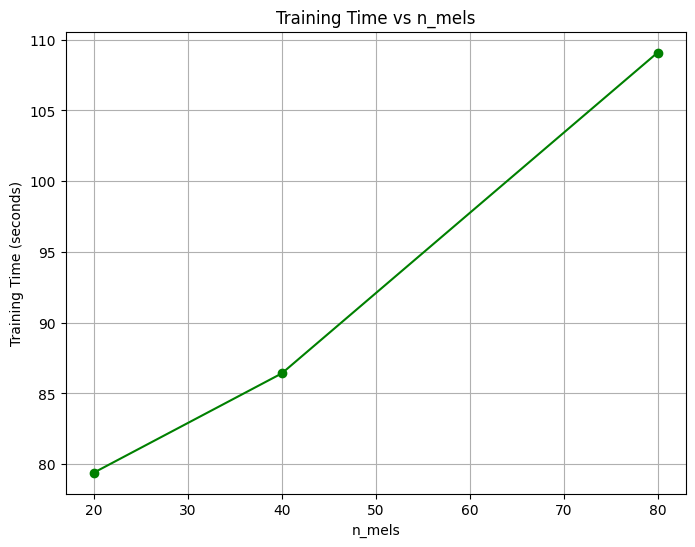

In [ ]:
#preparing visuals

import matplotlib.pyplot as plt

def plot_results(results):

    n_mels_vals = [result['n_mels'] for result in results]
    train_loss_vals = [result['train_loss'] for result in results]
    val_loss_vals = [result['val_loss'] for result in results]
    train_acc_vals = [result['train_acc'] for result in results]
    val_acc_vals = [result['val_acc'] for result in results]
    train_time_vals = [result['train_time'] for result in results]

    # train Loss vs n_mels
    plt.figure(figsize=(8, 6))
    for i in range(len(results)):
        plt.plot(range(1, len(train_loss_vals[i])+1), train_loss_vals[i], label=f"n_mels = {n_mels_vals[i]}", marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss')
    plt.title('Train Loss vs n_mels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # validation Loss vs n_mels
    plt.figure(figsize=(8, 6))
    for i in range(len(results)):
        plt.plot(range(1, len(val_loss_vals[i])+1), val_loss_vals[i], label=f"n_mels = {n_mels_vals[i]}", marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss vs n_mels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # train Accuracy vs n_mels
    plt.figure(figsize=(8, 6))
    for i in range(len(results)):
        plt.plot(range(1, len(train_acc_vals[i])+1), train_acc_vals[i], label=f"n_mels = {n_mels_vals[i]}", marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Train Accuracy')
    plt.title('Train Accuracy vs n_mels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # validation Accuracy vs n_mels
    plt.figure(figsize=(8, 6))
    for i in range(len(results)):
        plt.plot(range(1, len(val_acc_vals[i])+1), val_acc_vals[i], label=f"n_mels = {n_mels_vals[i]}", marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy vs n_mels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # training Time vs n_mels
    plt.figure(figsize=(8, 6))
    plt.plot(n_mels_vals, train_time_vals, marker='o', color='green')
    plt.xlabel('n_mels')
    plt.ylabel('Training Time (seconds)')
    plt.title('Training Time vs n_mels')
    plt.grid(True)
    plt.show()


plot_results([result1, result2, result3])


###Results

In [ ]:
def average(values):
    return sum(values) / len(values)

df = pd.DataFrame([
    {
        "n_mels": result["n_mels"],
        "groups": result["groups"],
        "train_loss": average(result["train_loss"]),
        "val_loss": average(result["val_loss"]),
        "train_acc": average(result["train_acc"]),
        "val_acc": average(result["val_acc"]),
        "train_time": result["train_time"],
        "params": result["params"],
        "flops": result["flops"]
    }
    for result in [result1, result2, result3]
])


df




,n_mels,groups,train_loss,val_loss,train_acc,val_acc,train_time,params,flops
0,20,1,0.127290,0.104569,0.953209,0.967995,79.393780,13057,1.278977
1,40,1,0.115153,0.101629,0.958651,0.966002,86.406706,25857,2.520577
2,80,1,0.118338,0.106330,0.958257,0.964384,109.079119,51457,5.003777


+ **Training Loss vs n_mels:**

As the number of Mel banks increases, the training loss decreases. The model learns better with a higher number of frequency bins.

The drop in loss is especially noticeable between 20 and 40 Mel banks, after which the reduction becomes less significant.

+ **Validation Loss vs n_mels**:

Validation loss decreases as the number of Mel banks increases up to 40. Beyond 40 Mel banks, the improvement becomes less pronounced.

+ **Training Accuracy vs n_mels**:

Training accuracy increases with the number of Mel banks. There is a sharp rise from 20 to 40 Mel banks, after which accuracy stabilizes.

A richer feature representation helps the model better capture hidden patterns.

+ **Validation Accuracy vs n_mels**:

Validation accuracy peaks at 40 Mel banks and then starts to fluctuate. Increasing the number of Mel banks from 20 to 40 improves accuracy, but going beyond 40 may lead to overfitting or unnecessary model complexity.

After a certain point (40), increasing the number of Mel banks no longer provides significant gains and only increases computational cost.



**Conclusion**

Based on the results, we can conclude that 40 Mel banks is the optimal choice, as it provides a good balance between performance and computational efficiency. Increasing the number of banks up to 80 brings only minimal accuracy improvements while significantly increasing training time.

However, since in the next assignment I plan to experiment with 16 groups as well, it will be more convenient for me to use **n_mels = 80** results as a baseline

##Experimenting with groups parameter of Conv1d layer

In [ ]:
#creating 1st experiment-like function

def run_experiment_with_groups(n_mels=80, batch_size=32, epochs=10):
    #params we're gonna change
    groups_values = [2, 4, 8, 16]

    results = []

    for groups in groups_values:
        print(f"\n n_mels={n_mels}, groups={groups}, epochs={epochs}")

        # LogMel layers
        logmel = LogMelFilterBanks(n_mels=n_mels)

        # ds
        train_ds = YesNoDataset(train_yesno, logmel)
        val_ds = YesNoDataset(val_yesno, logmel)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        class SimpleCNN(nn.Module):
            def __init__(self, n_mels, groups=1):
            super().__init__()
            self.conv = nn.Conv1d(n_mels, 128, kernel_size=5, groups=groups)
            self.pool = nn.AdaptiveAvgPool1d(1)
            self.fc = nn.Linear(128, 1)

            def forward(self, x):
            x = self.conv(x)
            x = torch.relu(x)
            x = self.pool(x)
            x = x.squeeze(-1)
            x = self.fc(x)
            return x.squeeze(1)


        # model
        model = SimpleCNN(n_mels=n_mels, groups=groups)

        if groups == 2:
          torch.save(model.state_dict(), "model_group2.pth")
          print(" Сохранена модель с group=2 как model_group2.pth") #позже вручную сохранила, чтобы отдельно загрузить веса по лучшей

        # optimizer and loss
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.BCEWithLogitsLoss()

        # metrics
        macs, params = get_model_complexity_info(
            model,
            input_res=(n_mels, 101),
            as_strings=False,
            print_per_layer_stat=False,
            verbose=False,
        )
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        all_train_loss = []
        all_train_acc = []
        all_val_loss = []
        all_val_acc = []
        start = time.time()

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs}")

            train_loss, train_acc, _ = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
            val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

            all_train_loss.append(train_loss)
            all_train_acc.append(train_acc)
            all_val_loss.append(val_loss)
            all_val_acc.append(val_acc)

        train_time = time.time() - start


        results.append({
            "n_mels": n_mels,
            "groups": groups,
            "train_loss": all_train_loss,
            "val_loss": all_val_loss,
            "train_acc": all_train_acc,
            "val_acc": all_val_acc,
            "train_time": train_time,
            "params": total_params,
            "flops": macs / 1e6
        })

    return results


In [ ]:
results = run_experiment_with_groups(n_mels=80, batch_size=32, epochs=10)


 n_mels=80, groups=2, epochs=10
 Сохранена модель с group=2 как model_group2.pth
Epoch 1/10


100%|██████████| 199/199 [00:08<00:00, 23.58it/s]


Epoch 2/10


100%|██████████| 199/199 [00:08<00:00, 23.60it/s]


Epoch 3/10


...

100%|██████████| 199/199 [00:08<00:00, 24.64it/s]


Epoch 9/10


100%|██████████| 199/199 [00:08<00:00, 24.61it/s]


Epoch 10/10


100%|██████████| 199/199 [00:07<00:00, 27.00it/s]


###Results

In [ ]:
df_groups = pd.DataFrame(results)

In [ ]:
df_groups

,n_mels,groups,train_loss,val_loss,train_acc,val_acc,train_time,params,flops
0,80,2,"[0.2981751803215125, 0.1738549147793396, 0.147...","[0.2265757925521869, 0.1717110246133346, 0.164...","[0.8787354513998112, 0.9340987731991193, 0.945...","[0.9140722291407223, 0.9576587795765878, 0.956...",88.676677,25857,2.520577
1,80,4,"[0.3806138383084206, 0.22496489959595792, 0.18...","[0.27257235090319926, 0.2132769527916725, 0.21...","[0.8364265492293174, 0.9208870714061026, 0.937...","[0.9190535491905355, 0.9315068493150684, 0.948...",88.829123,13057,1.278977
2,80,8,"[0.4610445871574795, 0.27301352149128316, 0.22...","[0.32556632017860043, 0.2921073084267286, 0.22...","[0.7955331865366467, 0.8965083359547027, 0.917...","[0.8916562889165629, 0.9053549190535491, 0.945...",84.526245,6657,0.658177
3,80,16,"[0.48065262396431446, 0.316471711325286, 0.272...","[0.3607695962374027, 0.2939249328695811, 0.254...","[0.7889273356401384, 0.8798364265492293, 0.899...","[0.8555417185554172, 0.8816936488169365, 0.910...",86.195885,3457,0.347777


In [ ]:
df_groups.loc[df_groups["val_acc"].apply(lambda x: max(x)).idxmax()] #in search of the best groups param

,0
n_mels,80
groups,2
train_loss,"[0.2981751803215125, 0.1738549147793396, 0.147..."
val_loss,"[0.2265757925521869, 0.1717110246133346, 0.164..."
train_acc,"[0.8787354513998112, 0.9340987731991193, 0.945..."
val_acc,"[0.9140722291407223, 0.9576587795765878, 0.956..."
train_time,88.676677
params,25857
flops,2.520577
avg_train_loss,0.132739


In [ ]:
cols_to_avg = ["train_loss", "val_loss", "train_acc", "val_acc"]
for col in cols_to_avg:
    df_groups[f"avg_{col}"] = df_groups[col].apply(lambda x: sum(x) / len(x) if isinstance(x, list) else x)

print(df_groups)



   n_mels  groups                                         train_loss                                           val_loss                                          train_acc                                            val_acc  train_time  params     flops  avg_train_loss  avg_val_loss  avg_train_acc  avg_val_acc
0      80       2  [0.2981751803215125, 0.1738549147793396, 0.147...  [0.2265757925521869, 0.1717110246133346, 0.164...  [0.8787354513998112, 0.9340987731991193, 0.945...  [0.9140722291407223, 0.9576587795765878, 0.956...   88.676677   25857  2.520577        0.132739      0.143994       0.952029     0.958406
1      80       4  [0.3806138383084206, 0.22496489959595792, 0.18...  [0.27257235090319926, 0.2132769527916725, 0.21...  [0.8364265492293174, 0.9208870714061026, 0.937...  [0.9190535491905355, 0.9315068493150684, 0.948...   88.829123   13057  1.278977        0.164851      0.185055       0.939761     0.953300
2      80       8  [0.4610445871574795, 0.27301352149128316, 0.22...  

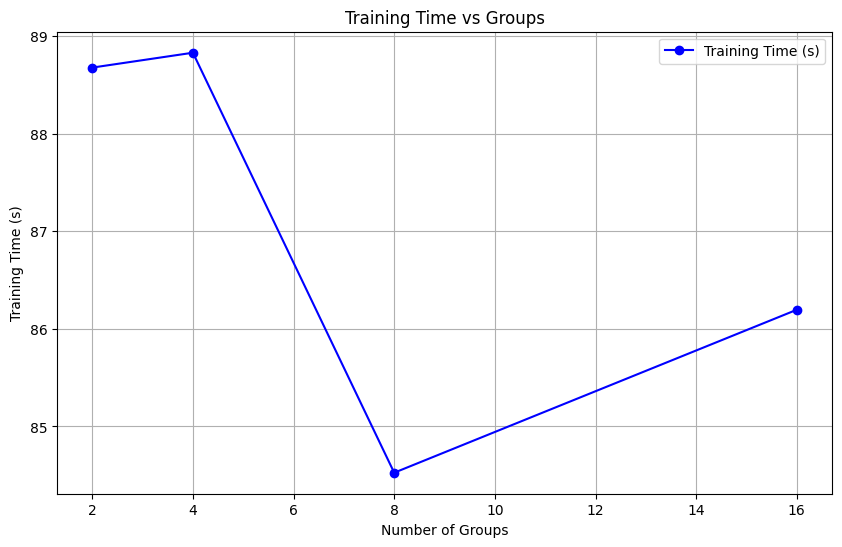

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_groups["groups"], df_groups["train_time"], marker='o', color='b', label='Training Time (s)')
plt.xlabel("Number of Groups")
plt.ylabel("Training Time (s)")
plt.title("Training Time vs Groups")
plt.legend()
plt.grid(True)
plt.show()

**Training Time vs Groups**

Training time noticeably decreases as the number of groups increases from 2 to 16. Training time is significantly higher with 2 groups, then drops at 8 groups, and increases again at 16 groups.

This could be related to how computations are distributed across groups in different configurations(?).

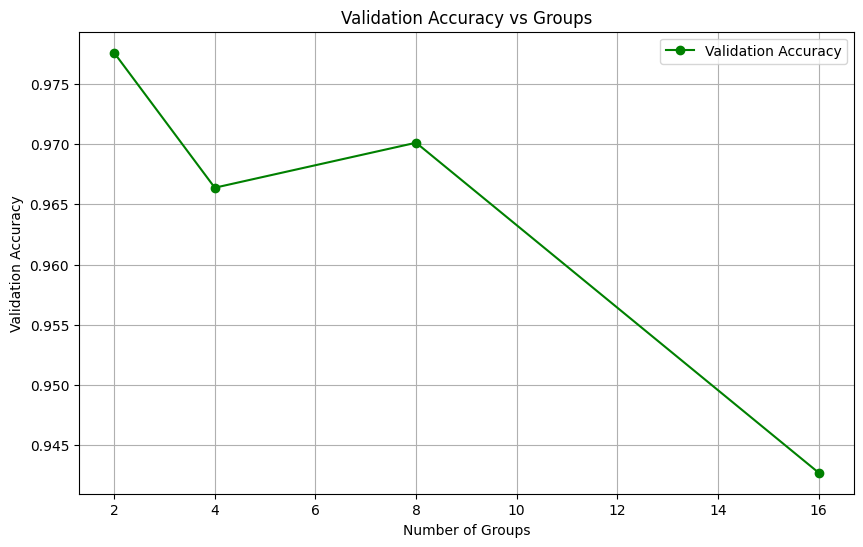

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_groups["groups"], df_groups["val_acc"].apply(lambda x: max(x)), marker='o', color='g', label='Validation Accuracy')
plt.xlabel("Number of Groups")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Groups")
plt.legend()
plt.grid(True)
plt.show()


**Validation Accuracy vs Groups**

The highest validation accuracy was achieved with 2 groups, after which accuracy declines as the number of groups increases.

This may suggest that increasing the number of groups reduces the model’s ability to generalize, as higher group values lead to fewer parameters and lower complexity.

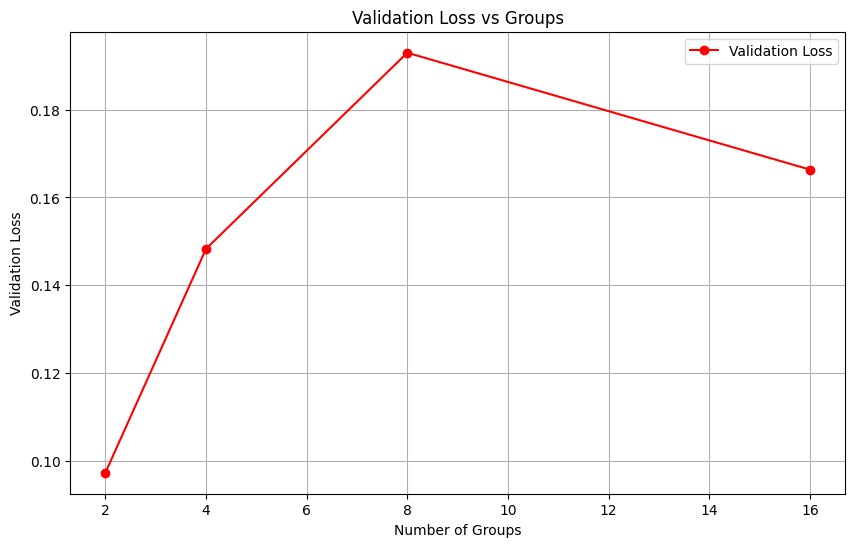

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_groups["groups"], df_groups["val_loss"].apply(lambda x: min(x)), marker='o', color='r', label='Validation Loss')
plt.xlabel("Number of Groups")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Groups")
plt.legend()
plt.grid(True)
plt.show()


**Validation Loss vs Groups**

Validation loss increases as the number of groups increases, which supports the conclusion from the accuracy graph. A larger number of groups may not be optimal for this model, as it leads to decreased performance.

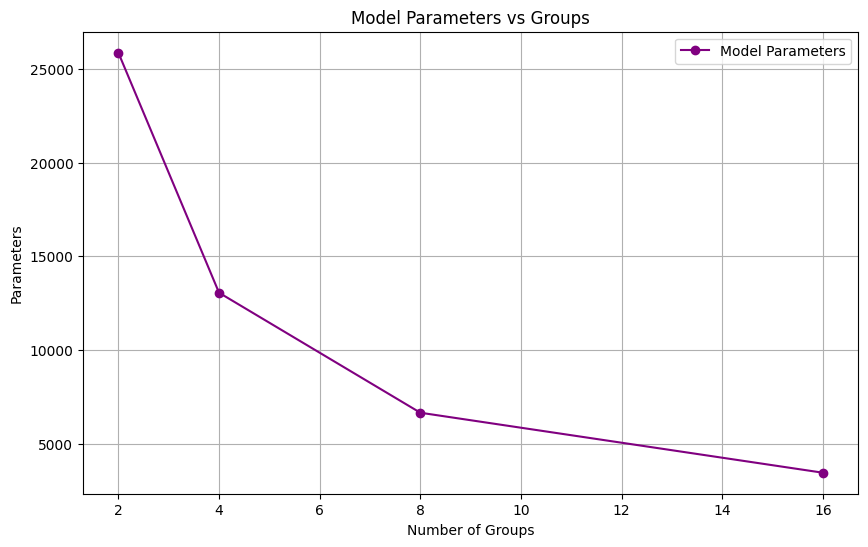

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_groups["groups"], df_groups["params"], marker='o', color='purple', label='Model Parameters')
plt.xlabel("Number of Groups")
plt.ylabel("Parameters")
plt.title("Model Parameters vs Groups")
plt.legend()
plt.grid(True)
plt.show()


**Model Parameters vs Groups**

We observe a sharp reduction in the number of model parameters as the number of groups increases. This happens because more groups split the parameters into smaller subgroups, reducing the overall complexity of the model.

For example, using 2 groups results in significantly more parameters than using 16 groups.

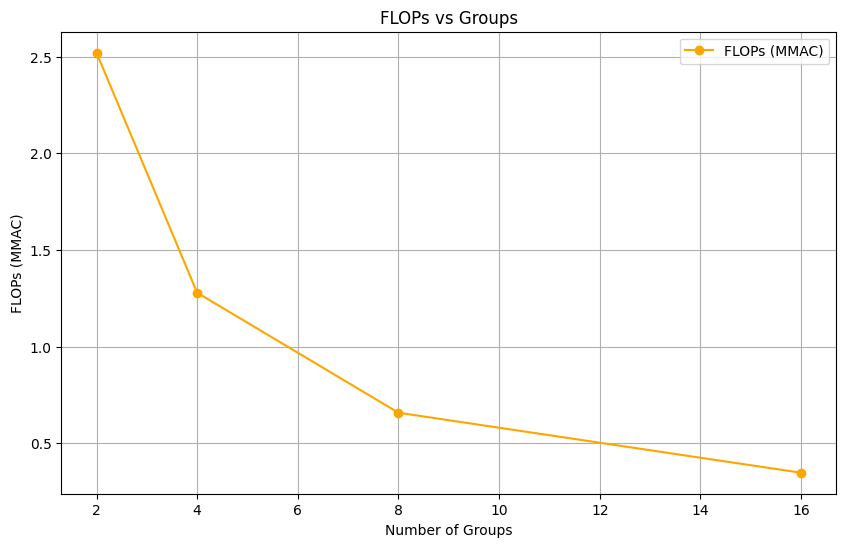

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_groups["groups"], df_groups["flops"], marker='o', color='orange', label='FLOPs (MMAC)')
plt.xlabel("Number of Groups")
plt.ylabel("FLOPs (MMAC)")
plt.title("FLOPs vs Groups")
plt.legend()
plt.grid(True)
plt.show()


**FLOPs vs Groups**

The number of FLOPs also sharply decreases as the number of groups increases, meaning that models with more groups are more efficient computationally — but this comes at the cost of reduced performance.

**Conclusion**

Based on the experimental results, we can conclude that smaller group values (2 or 4) yield better validation accuracy, while increasing the number of groups negatively impacts prediction quality.

## Baseline(group=1, n_mel = 80) vs. BestGroup(group=2, n_mel=80) on testing set

first, i'm gonna run the experiment_1 once again to save the loads of the baseline model(the second ones are already saved)

In [ ]:
def run_experiment(n_mels=80, groups=1, batch_size=32, epochs=10):
    print(f"\n n_mels={n_mels}, groups={groups}, epochs={epochs}")

    # LogMel layer
    logmel = LogMelFilterBanks(n_mels=n_mels)

    # datasets we need
    train_ds = YesNoDataset(train_yesno, logmel)
    val_ds = YesNoDataset(val_yesno, logmel)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    # model
    model = SimpleCNN(n_mels=n_mels, groups=groups).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    macs, params = get_model_complexity_info(
        model,
        input_res=(n_mels, 101),
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False,
    )
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    all_train_loss = []
    all_train_acc = []
    all_val_loss = []
    all_val_acc = []
    start = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        train_loss, train_acc, _ = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        all_train_loss.append(train_loss)
        all_train_acc.append(train_acc)
        all_val_loss.append(val_loss)
        all_val_acc.append(val_acc)

    train_time = time.time() - start

    # saving the model
    torch.save(model.state_dict(), "model_group1.pth")


    return model, {
        "n_mels": n_mels,
        "groups": groups,
        "train_loss": all_train_loss,
        "val_loss": all_val_loss,
        "train_acc": all_train_acc,
        "val_acc": all_val_acc,
        "train_time": train_time,
        "params": total_params,
        "flops": macs / 1e6
    }


In [ ]:
model1, result1 = run_experiment(n_mels=80, groups=1, batch_size=32, epochs=10)


 n_mels=80, groups=1, epochs=10
Epoch 1/10


100%|██████████| 199/199 [00:09<00:00, 21.70it/s]


Epoch 2/10


100%|██████████| 199/199 [00:08<00:00, 22.83it/s]


Epoch 3/10


...

100%|██████████| 199/199 [00:09<00:00, 21.87it/s]


Epoch 9/10


100%|██████████| 199/199 [00:09<00:00, 20.83it/s]


Epoch 10/10


100%|██████████| 199/199 [00:09<00:00, 20.94it/s]


In [ ]:
def load_and_test_model(n_mels, groups, path):

    model = SimpleCNN(n_mels=n_mels, groups=groups).to(device)
    model.load_state_dict(torch.load(path))
    model.eval()

    logmel = LogMelFilterBanks(n_mels=n_mels)
    test_ds = YesNoDataset(test_yesno, logmel)
    test_loader = DataLoader(test_ds, batch_size=32)

    loss_fn = nn.BCEWithLogitsLoss()
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    print(f" {path}: Test Loss = {test_loss:.4f}, Accuracy = {test_acc:.4f}")
    return test_loss, test_acc


In [ ]:
load_and_test_model(n_mels=80, groups=1, path="model_group1.pth")
load_and_test_model(n_mels=80, groups=2, path="model_group2.pth")


 model_group1.pth: Test Loss = 0.0842, Accuracy = 0.9697
 model_group2.pth: Test Loss = 0.6180, Accuracy = 0.6529


(0.6180385672129117, 0.6529126213592233)

###Results

The model with grouped convolutions (Group = 2) performed significantly worse on the test set.
Although it showed the best results on the validation set, it turned out to be overfitted or poorly generalizing on the test data.

**Conclusion**

The baseline (Group = 1) clearly outperformed it — with nearly 97% accuracy and very low loss.

It is possible that groups=2 performed well on validation but overfitted.
Alternatively, its architecture may generalize poorly due to an insufficient number of parameters.
In the future, it might be worth testing groups=4 or 8 to find a better balance between model capacity and generalization.